In [1]:
import glob 
import pandas as pd
import random 
import cv2 
import numpy as np
import re
import os
import json
import csv
import matplotlib.pyplot as plt  
import google.genai as genai
from typing import List, Dict, Tuple
from datetime import datetime
from paddleocr import PaddleOCR
from pathlib import Path
from difflib import SequenceMatcher
from dotenv import load_dotenv

import warnings
warnings.filterwarnings('ignore')

c:\Users\Bvarta-Aditya\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### Load Image

In [2]:
# Folder configuration
BASE_DIR = Path(os.getcwd())
INPUT_FOLDER = BASE_DIR.parent/'data_raw'/'benchmark_input_images'
PROCESSED_FOLDER = BASE_DIR.parent/'data_raw'/'benchmark_processed_images'

In [3]:
# Check image
images = glob.glob(str(INPUT_FOLDER) + "/**/*.jpg", recursive=True)
print("Total images:", len(images))

Total images: 6


(-0.5, 1839.5, 3999.5, -0.5)

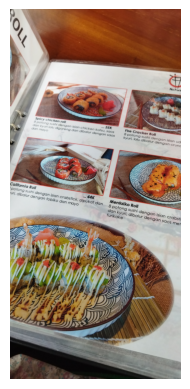

In [4]:
# Load images
img_path = images[3]
img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

### Run OCR

In [5]:
# Run PaddleOCR
engine = PaddleOCR(use_angle_cls=True, 
                   lang='en', 
                   det_db_thresh=0.20, 
                   det_db_box_thresh=0.30,
                   det_db_unclip_ratio=2.0,
                   show_log=False  
 
)

# Run on image path
results = engine.ocr(img_path, cls=True)

# Iterate through the first page and print
for line in results[0]:
    print(line[1][0])

OLL
No Por
Spicy chicken roll
8 potong sushi dengan isian chicken katsu,saos
35K
dan mayo
Fire Cracker Roll
8 potong sushi dengan isian ud
kyuri lalu dibalur dengan crun
California Roll
potong sushi dengan isian crabstick, alpukat dan
uri dibalur dengan tobiko dan mayo
.44K
Mentaiko Roll
8 potong sushi dengan isian crabst
dan kyuri, dibalur dengan saos mer
furikake


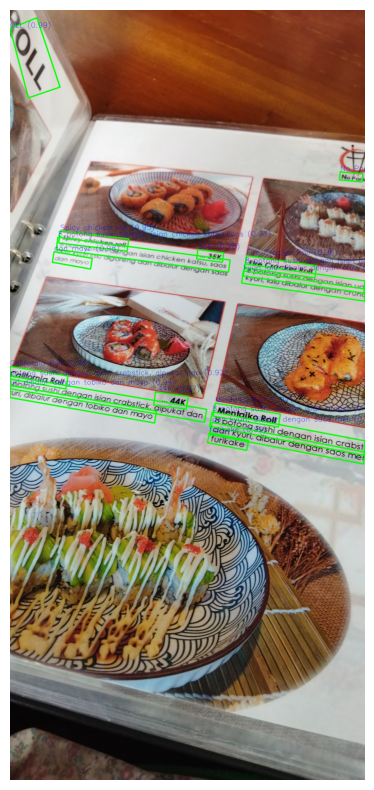

In [6]:
# Make the OCR readable
def draw_boxes(image_bgr, results):
    img = image_bgr.copy()
    # PaddleOCR results 
    for line in results[0]:
        box = line[0]        # Bounding box coordinates
        text = line[1][0]    # Extracted text
        conf = line[1][1]    # Confidence score
        
        # Draw polyline
        pts = np.array(box, dtype=np.int32)
        cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=5)
        
        # Put text
        x, y = pts[0]
        cv2.putText(img, f"{text} ({conf:.2f})", (x, int(y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.25, (255, 0, 0), 1, cv2.LINE_AA)
    
    return img 

# Process and plot
boxed = draw_boxes(img, results)
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Image Post-Processing

Split fused token

In [7]:
# Split fused function
def split_fused_token(token: str) -> list:
    # Price at start, UPPERCASE text after K (category fused)
    # '..18KNOMU' → ['..18K', 'NOMU']
    match = re.match(r'^([.\s]*\d+\s*[Kk])\s*([A-Z]{2,}.*)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]

    # Price at start, mixed case text after K
    # '..32 K Ocha (Free Refill)' → ['..32K', 'Ocha (Free Refill)']
    match = re.match(r'^([.\s]*\d+\s*[Kk])\s+([A-Za-z].+)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]

    # Text at start, price at end                          ← NEW
    # 'Sapporo Gyu Udon ..45k' → ['Sapporo Gyu Udon', '..45k']
    match = re.match(r'^([A-Za-z][A-Za-z\s]+?)\s*([.\s]*\d+\s*[Kk][RLrl]?.*)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]

    # Text at start, price after (no dots)
    # 'NOMU18K' → ['NOMU', '18K']
    match = re.match(r'^([A-Za-z][A-Za-z\s]+?)\s*(\d+\s*[Kk].*)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]
    
    # '..7K 2025/7/16 12:32' → ['..7K', '2025/7/16 12:32']
    match = re.match(r'^([.\s]*\d+\s*[Kk])\s+(\d{4}[/-]\d+.*)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]
    
    # O/0 before digits = OCR noise for price separator
    match = re.match(r'^([A-Za-z][A-Za-z\s]+?)\s*[O0]\s*(\d+\s*[Kk].*)$', token)
    if match:
        return [match.group(1).strip(), match.group(2).strip()]

    return [token]

Menu item structure

In [8]:
def is_menu_item_name(token: str) -> bool:
    """
    Item names are short, title-cased, and don't look like descriptions.
    Descriptions are long, lowercase, and contain connector words.
    """
    words = token.strip().split()

    # Too long — likely a description
    if len(words) > 5:
        return False

    # Too short — likely noise
    if len(words) < 1:
        return False

    # Starts with lowercase connector word — likely description fragment
    first_word = words[0].lower()
    if first_word in {'dan', 'dengan', 'atau', 'di', 'ke', 'yang', 'dan', 
                      'lalu', 'serta', 'dari', 'untuk', 'ini', 'itu'}:
        return False

    # Starts with digit — likely description ('8 potong sushi')
    if re.match(r'^\d+\s+[a-z]', token):
        return False

    return True

Parse variant prices

In [9]:
# Variant price function
def parse_variant_prices(text: str) -> list:
    suffixes    = {'K': 1000, 'k': 1000, 'RB': 1000, 'rb': 1000, 'JT': 1000000}
    variant_map = {'R': 'Regular', 'S': 'Small', 'M': 'Medium', 'L': 'Large', 'XL': 'Extra Large', 'O': 'Original'}
    min_price   = 1000
    max_price   = 5000000

    suffix_pat = 'K|k|RB|rb|JT'

    block_re = re.compile(
        rf'(\d[\d.,]*)'                    # number       → group 1
        rf'\s*(?:({suffix_pat}))?'         # suffix K/RB  → group 2
        rf'\s*(?:\(([A-Za-z]{{1,5}})\))?'  # (TAG)        → group 3
    )

    results = []
    for m in block_re.finditer(text):
        raw_num, suffix, tag = m.group(1), m.group(2), m.group(3)

        # Skip if number followed by multiple words
        after = text[m.end():].strip()
        if re.match(r'^[a-zA-Z]{2,}', after) and not suffix and not tag:
            continue

        try:
            amount = float(raw_num.replace(',', '.'))
        except ValueError:
            continue

        if suffix:
            amount *= suffixes.get(suffix.upper(), 1)

        if not (min_price <= amount <= max_price):
            continue

        tag_upper = tag.upper() if tag else None
        results.append({
            'amount':  int(amount),
            'tag':     tag,
            'variant': variant_map.get(tag_upper) if tag_upper else None,
        })

    return results

Skip headers

In [10]:
# Skip patterns function
def is_skip(token: str) -> bool:
    SKIP_PATTERNS = [
        r'^\d{4}-\d{4}-\d{4}$',    
        r'^[a-z][a-z0-9_.]+$',          
        r'^NO\s',    
        r'NO\s+(PORK|LARD|MIRIN|MSG|ALCOHOL)',   
        r'.*NO\s+LARD.*NO\s+MIRIN.*',
        r'^\*',                   
        r'^[.…]+$',
        r'^["\']+[.\s]*["\']*$',
        r'^\d{4}/\d{1,2}/\d{1,2}',          
        r'^\d{4}-\d{1,2}-\d{1,2}',           
        r'\d{1,2}:\d{2}$',                                            
    ]
    return any(re.search(p, token) for p in SKIP_PATTERNS)

Price

In [11]:
# Price function
def looks_like_price(token: str) -> bool:
    # Must contain at least one digit
    if not re.search(r'\d', token):
        return False
    # Must contain K, k, RB, or IDR-style suffix OR a number >= 3 digits
    return bool(re.search(r'\d+\s*[Kk]\b', token) or
                re.search(r'\d{4,}', token))

Normalize price strings

In [12]:
# Normalize price function
def normalize_price_string(raw: str) -> str:
    # Strip leading dots/spaces
    s = re.sub(r'^[.\s]+', '', raw)

    # Fix missing space between two price blocks
    s = re.sub(r'(\d+\s*[Kk])\s*([RLSMrlsm])\s*(\d)', r'\1(\2) \3', s)

    # Normalize K immediately followed by R/L (no parenthesis)
    s = re.sub(r'(\d+\s*[Kk])\s*([RLSMrlsm])\b', r'\1(\2)', s)

    # Fix missing opening parenthesis
    s = re.sub(r'(\d+\s*[Kk])\s*([RLSMrlsm])\)', r'\1(\2)', s)

    # Fix missing closing parenthesis
    s = re.sub(r'(\d+\s*[Kk]\s*\([RLSMrlsm])\s*$', r'\1)', s)

    # Fix missing closing parenthesis followed by digit
    s = re.sub(r'(\d+\s*[Kk]\s*\([RLSMrlsm])(\d)', r'\1) \2', s)

    # Fix missing closing parenthesis followed by space and digit
    s = re.sub(r'(\d+\s*[Kk]\s*\([RLSMrlsm])\s+(\d)', r'\1) \2', s)

    # Ensure space between price blocks
    s = re.sub(r'(\))\s*(\d)', r'\1 \2', s)

    # Add missing K before R/L/S/M
    s = re.sub(r'(\d+)\s*(\([RLSMrlsm]\))', r'\1K\2', s)

    # Fix OCR noise between price pairs
    s = re.sub(r'(\d+\s*[Kk])\s*[Il|/\\]\s*(\d)', r'\1 \2', s)

    # Remove date/time suffixes
    s = re.sub(r'\s*\d{4}[/-]\d{1,2}[/-]\d{1,2}.*$', '', s) 
    s = re.sub(r'\s*\d{1,2}:\d{2}.*$', '', s)

    # '0...41K' → OCR read O as 0 → strip leading non-price chars
    s = re.sub(r'^[OSos]\.*\s*(\d)', r'\1', s)        # ← NEW: strip O/S prefix

    # Fix 'S...42K' → '42K(S)'
    s = re.sub(r'^([SMLRslmr])[.\s]*(\d+\s*[Kk])', r'\2(\1)', s)   

    s = re.sub(r'^\d[.\s]+(\d)', r'\1', s)               

    return s.strip()

Merge token

In [13]:
def merge_tokens(tokens: list, y_coords: list = None) -> list:
    # Step 1 — split fused tokens
    split_tokens = []
    split_y      = []
    for token, y in zip(tokens, y_coords or [0] * len(tokens)):
        parts = split_fused_token(token)
        for part in parts:
            split_tokens.append(part)
            split_y.append(y)        # ← keep y in sync

    # Step 2 — merge
    merged   = []
    merged_y = []
    i = 0
    while i < len(split_tokens):
        token      = split_tokens[i]
        y          = split_y[i]
        normalized = normalize_price_string(token)
        prices     = parse_variant_prices(normalized)

        # Skip merge if current token already has 2+ prices
        if len(prices) >= 2:
            merged.append(token)
            i += 1
            continue

        next_token  = split_tokens[i + 1] if i + 1 < len(split_tokens) else None
        next_y      = split_y[i + 1]      if i + 1 < len(split_y)      else None
        next_prices = parse_variant_prices(normalize_price_string(next_token)) if next_token else []

        tagged_merge = (
            prices and next_prices and
            prices[0]['tag'] is not None and
            prices[0]['tag'].upper() in ['R', 'S', 'M', 'L']
        )

        untagged_merge = (
            prices and next_prices and
            prices[0]['tag'] is None and
            next_prices[0]['tag'] is None
        )

        if tagged_merge or untagged_merge:
            merged.append(token + ' ' + next_token)
            merged_y.append(y)
            i += 2
        else:
            merged.append(token)
            merged_y.append(y)
            i += 1

    return merged

Group by rows

In [14]:
# Group function
def group_by_rows(ocr_result, y_threshold=40) -> list:
    # Flatten and format
    raw_boxes = ocr_result[0] if isinstance(ocr_result[0], list) else ocr_result
    boxes = []
    for line in raw_boxes:
        bbox, (text, conf) = line
        boxes.append({
            'text':    text,
            'x_left':  bbox[0][0],
            'x_right': bbox[1][0],
            'y':       (bbox[0][1] + bbox[2][1]) / 2,
            'conf':    conf
        })

    # Filter descriptions before grouping        ← moved here
    boxes = [
        b for b in boxes
        if parse_variant_prices(normalize_price_string(b['text']))   # keep prices
        or (not is_skip(b['text']) and is_menu_item_name(b['text'])) # keep item names
    ]

    # Sort top-to-bottom
    boxes.sort(key=lambda b: b['y'])

    rows = []
    if not boxes:
        return rows

    # Group by y anchor
    current_row = [boxes[0]]
    for i in range(1, len(boxes)):
        if abs(boxes[i]['y'] - current_row[0]['y']) <= y_threshold:
            current_row.append(boxes[i])
        else:
            current_row.sort(key=lambda b: b['x_left'])
            rows.append(current_row)
            current_row = [boxes[i]]

    current_row.sort(key=lambda b: b['x_left'])
    rows.append(current_row)

    # Split rows with large x gap
    final_rows = []
    for row in rows:
        temp_row = [row[0]]
        for j in range(1, len(row)):
            gap = row[j]['x_left'] - row[j-1]['x_right']
            if gap > 400:
                final_rows.append(temp_row)
                temp_row = [row[j]]
            else:
                temp_row.append(row[j])
        final_rows.append(temp_row)

    return final_rows

Classify token

In [15]:
# Classify token function
def classify_token(token: str) -> str:
    if is_skip(token):                                          
        return 'skip'
    if parse_variant_prices(normalize_price_string(token)):     
        return 'price'  
    return 'name'

### Test Process OCR
Apply to single image

In [16]:
# Process tokens function
def process_tokens(tokens: list) -> list:
    results = []
    current_name = None
    current_price = None

    for token in tokens:
        kind = classify_token(token)
        
        if kind == 'skip':
            continue
        if kind == 'name':
            current_name = token
            continue
        if kind == 'price':
            if current_name is None:
                continue  # Price with no name, skip

            normalized = normalize_price_string(token)
            prices = parse_variant_prices(normalized)

            item = {'name': current_name}
            if len(prices) == 1 and prices[0]['tag'] is None:
                item['price'] = prices[0]['amount']
            else:
                item['prices'] = prices
            results.append(item)
            current_name = None 
            current_price = None

    return results

# Process the tokens
rows   = group_by_rows(results)
tokens = []
for row in rows:
    fixed_row = row
    for box in fixed_row:
        tokens.append(box['text'])

tokens = merge_tokens(tokens)
menu_items = process_tokens(tokens)
menu_items

[{'name': 'Spicy chicken roll', 'price': 35000},
 {'name': 'California Roll', 'price': 44000}]

### Debug

Debug coordinate position

In [17]:
rows   = group_by_rows(results)
tokens = []
for row in rows:
    fixed_row = row
    for box in fixed_row:
        print(f"x={box['x_left']:6.0f}  y={box['y']:6.0f}  {repr(box['text']):40s} → {classify_token(box['text'])}")
        tokens.append(box['text'])

x=     0  y=   248  'OLL'                                    → name
x=  1711  y=   866  'No Por'                                 → name
x=   260  y=  1200  'Spicy chicken roll'                     → name
x=   973  y=  1277  '35K'                                    → price
x=  1225  y=  1334  'Fire Cracker Roll'                      → name
x=  1209  y=  1434  'kyuri lalu dibalur dengan crun'         → name
x=     0  y=  1910  'California Roll'                        → name
x=   753  y=  2028  '.44K'                                   → price
x=  1063  y=  2104  'Mentaiko Roll'                          → name


Debug merge tokens

In [18]:
tokens = merge_tokens(tokens)
tokens

['OLL',
 'No Por',
 'Spicy chicken roll',
 '35K',
 'Fire Cracker Roll',
 'kyuri lalu dibalur dengan crun',
 'California Roll',
 '.44K',
 'Mentaiko Roll']

Debug classify tokens

In [19]:
tokens = merge_tokens(tokens)
for t in tokens:
    print(repr(t), '→', classify_token(t))

'OLL' → name
'No Por' → name
'Spicy chicken roll' → name
'35K' → price
'Fire Cracker Roll' → name
'kyuri lalu dibalur dengan crun' → name
'California Roll' → name
'.44K' → price
'Mentaiko Roll' → name


### Process All Images
Apply to all images on the image path

In [20]:
# Process all images function
def process_all_images(engine) -> list:
    image_files = glob.glob(str(INPUT_FOLDER) + "/**/*.jpg", recursive=True)
    all_results = []

    for image_path in image_files:
        image_name = Path(image_path).name
        poi_id = image_name.split('_')[0]
        print(f"Processing {image_name} (poi_id={poi_id})...")

        # OCR
        results = engine.ocr(image_path, cls=True)
        if not results or not results[0]:
            print(f"No text detected")
            continue
        
        # Layout fixing
        rows   = group_by_rows(results)
        tokens = []
        for row in rows:
            fixed_row = row
            for box in fixed_row:
                tokens.append(box['text'])
        
        tokens = merge_tokens(tokens)
        menu_items = process_tokens(tokens)

        all_results.append({
            'poi_id': poi_id,
            'image': Path(image_path).name,
            'total_items': len(menu_items),
            'items': menu_items
        })

        print(f"{len(menu_items)} items extracted")

    return all_results

all_results = process_all_images(engine)

Processing poiabc123_foto_14_.jpg (poi_id=poiabc123)...
1 items extracted
Processing poiabc123_foto_19_Ilham_Pratama.jpg (poi_id=poiabc123)...
15 items extracted
Processing poiabc123_foto_28_Heppi_Elastiko.jpg (poi_id=poiabc123)...
24 items extracted
Processing poiabc123_foto_49_Gitta_Fatima_Rahayu.jpg (poi_id=poiabc123)...
2 items extracted
Processing poiabc123_foto_57_Ilham_Pratama.jpg (poi_id=poiabc123)...
2 items extracted
Processing poiabc123_foto_63_Wahyu_Ramadhan.jpg (poi_id=poiabc123)...
2 items extracted


In [21]:
# Check results
all_results[3]

{'poi_id': 'poiabc123',
 'image': 'poiabc123_foto_49_Gitta_Fatima_Rahayu.jpg',
 'total_items': 2,
 'items': [{'name': 'Spicy chicken roll', 'price': 35000},
  {'name': 'California Roll', 'price': 44000}]}

In [22]:
# Convert to pandas df
#df_all_results = pd.DataFrame(all_results)

# Save to JSON
#df_all_results.to_json(r"C:\Users\Bvarta-Aditya\Workspace\fnb_menu\data_raw\benchmark_processed_images\ocr_results.json", orient='records', indent=4)

# Save to CSV
#df_all_results.to_csv(r"C:\Users\Bvarta-Aditya\Workspace\fnb_menu\data_raw\benchmark_processed_images\ocr_results.csv", index=False)

### Deduplication

Sequence matcher

In [23]:
# Calculate similarity function
def calculate_similarity(text1: str, text2: str) -> float:
    """Calculate similarity between two strings (0-1)."""
    return SequenceMatcher(None, text1.lower(), text2.lower()).ratio()

Deduplication menu items:
- Group identical name
- Remove near-dupes using similarity score (Sequence + Jaccard)

In [24]:
# Dedupe menu function
def dedupe_menu_items(items: list, threshold=0.85) -> list:
    """
    2-pass deduplication on structured menu items.
    Pass 1: Group identical name
    Pass 2: Remove near-duplicates using similarity
    """
    # Pass 1 — group identical name
    groups = {}
    for item in items:
        key = item.get('name', '').lower().strip()
        if key not in groups:
            groups[key] = item

    deduped = list(groups.values())

    # Pass 2 — remove near-duplicates by similarity
    final = []
    for item in deduped:
        is_dupe = False
        for kept in final:
            words_a = set(item.get('name', '').lower().split())
            words_b = set(kept.get('name', '').lower().split())
            if not words_a or not words_b:
                continue

            intersection = len(words_a & words_b)
            union        = len(words_a | words_b)
            jaccard      = intersection / union

            seq_sim = calculate_similarity(
                item.get('name', ''),
                kept.get('name', '')
            )

            score = (jaccard + seq_sim) / 2

            if score >= threshold:
                is_dupe = True
                break

        if not is_dupe:
            final.append(item)

    return final

Deduplication on all menu

In [25]:
# Deduplication all menu function
def dedupe_all(all_results: list, threshold=0.85) -> list:
    """Dedupe items across all images grouped by poi_id."""

    # Group by poi_id extracted from image filename
    poi_groups = {}
    for result in all_results:
        poi_id = result['image'].split('_')[0] 
        if poi_id not in poi_groups:
            poi_groups[poi_id] = []
        poi_groups[poi_id].append(result)

    final = []
    for poi_id, group in poi_groups.items():

        # Collect all items from all images for this POI
        all_items     = []
        for result in group:                   
            all_items.extend(result['items'])

        # Dedupe
        deduped = dedupe_menu_items(all_items, threshold=threshold)

        # Sort by name
        deduped.sort(key=lambda x: x.get('name') or '')

        final.append({
            'poi_id':        poi_id,
            'total_items':   len(deduped),
            'items': deduped
        })

    return final

# Usage
final_results = dedupe_all(all_results)
final_results

[{'poi_id': 'poiabc123',
  'total_items': 44,
  'items': [{'name': '6', 'price': 21000},
   {'name': 'Air Mineral', 'price': 7000},
   {'name': 'Ajitsuke Tamago', 'price': 5000},
   {'name': 'Avocado Coffee', 'price': 30000},
   {'name': 'Avocado Juice', 'price': 16000},
   {'name': 'Beef Curry Rice',
    'prices': [{'amount': 41000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 42000, 'tag': None, 'variant': None}]},
   {'name': 'California Roll', 'price': 44000},
   {'name': 'Chicken Katsu Curry', 'price': 35000},
   {'name': 'Chicken KatsuDon', 'price': 33000},
   {'name': 'Chocoreto Hot', 'price': 18000},
   {'name': 'Chocoreto Miruku', 'price': 21000},
   {'name': 'Chocoreto lce', 'price': 19000},
   {'name': 'Crispy Mayo Roll', 'price': 31000},
   {'name': 'Crunchy Roll', 'price': 39000},
   {'name': 'Ebi Cuny Rice O',
    'prices': [{'amount': 39000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 40000, 'tag': None, 'variant': None}]},
   {'name': 'Ebi Don', 'price': 36000}

### LLM
Use Gemini API LLM to perform data cleaning

In [26]:
# Get credentials in environment path
env_path = Path.home() / 'Workspace' / '.env'
home_env_loaded = load_dotenv(env_path)
print(f"Load from Workspace directory: {home_env_loaded} {env_path}")

Load from Workspace directory: True C:\Users\Bvarta-Aditya\Workspace\.env


In [27]:
# Set API_KEY
API_KEY = os.getenv('gemini_api_key')

In [28]:
# Setup
client = genai.Client(api_key=API_KEY)

In [29]:
def clean_menu_with_llm(raw_json_data):
   # Customize the prompt
   prompt = f"""
   You are an expert Data Auditor specialized in OCR post-processing for food and beverages menus.
   Review the following JSON data and apply these cleaning rules strictly:

   TASKS:
   1. LOGICAL PRICE SCALING:
      - Identify outliers where a price is missing digits (e.g., '50' instead of '50000').
      - Scale it to match the currency magnitude of the surrounding items in the same category.
      - All amounts must be integers.

   2. OCR CHARACTER CORRECTION:
      - Fix common OCR character swaps ONLY:
      * 'l' or 'I' misread as each other (e.g., 'lce' -> 'Ice')
      * '0' misread as 'O' or vice versa
      * Common doubled characters in NAMES caused by OCR
         (e.g., 'Teriyakii' -> 'Teriyaki', 'IICE' -> 'ICE', 'Chickenn' -> 'Chicken')
      * Only fix doubled characters if the result is a real recognizable word.
      - Fix clear spelling mistakes caused by OCR (e.g., 'Chiken' -> 'Chicken', 'Karaage' stays 'Karaage')
      - DO NOT translate any word to English or any other language.
      - DO NOT change local language words (e.g., 'Abokadojusu', 'Gyudon', 'Shoyu', 'Miruku', 'Ocha' must stay as-is).
      - DO NOT change brand names or restaurant-specific terms.

   3. NAME NORMALIZATION:
      - Apply Title Case consistently (e.g., 'spicy katsu curry' -> 'Spicy Katsu Curry', 'Chicken KatsuDon' -> 'Chicken Katsu Don').
      - Remove OCR noise from names: leading/trailing dots, slashes, timestamps.
      - DO NOT reorder words in a name.

   4. DEDUPLICATION:
      - If multiple items have EXACTLY the same name AND price → keep only 1.
      - If multiple items have very similar names (minor spacing/capitalization differences) 
      AND same price → keep only the best formatted one.
      - If items have the same or similar name but DIFFERENT prices → keep all.
      - Never merge items with different prices, even if names are identical.
   
   5. REMOVE ITEM
      - If name doesn't make sense (e.g., number in name 1 -> 'name': '1')

   5. STRICT RULES — NEVER DO:
      - Never translate local language words to English.
      - Never add fields that don't exist in the original.
      - Never remove items unless they are exact duplicates (same name + same price).

   Return ONLY the cleaned JSON. No explanation, no markdown, no extra text.

   RAW JSON:
   {json.dumps(raw_json_data, ensure_ascii=False)}
   """

   # Response to generate content
   response = client.models.generate_content(
      model="gemini-2.5-flash-lite", 
      contents=prompt
   )

   # Extract the text
   raw_text = response.text

   # Clean markdown formatting
   cleaned_text = raw_text.replace('```json', '').replace('```', '').strip()

   try:
      return json.loads(cleaned_text)
   except Exception as e:
      print(f"Error parsing LLM response: {e}")
      print(f"Full response was: {raw_text}") # Debugging: see what Gemini actually said
      return raw_json_data

In [30]:
# Apply LLM cleaning
final_menu_results = []
for group in final_results:
    cleaned = clean_menu_with_llm(group)

    # Handle if LLM returns list instead of dict
    if isinstance(cleaned, list):
        cleaned = {
            'poi_id':        group['poi_id'],
            'items':         cleaned
        }

    cleaned['total_items'] = len(cleaned['items'])
    final_menu_results.append(cleaned)

final_menu_results

[{'poi_id': 'poiabc123',
  'total_items': 43,
  'items': [{'name': 'Air Mineral', 'price': 7000},
   {'name': 'Ajitsuke Tamago', 'price': 5000},
   {'name': 'Avocado Coffee', 'price': 30000},
   {'name': 'Avocado Juice', 'price': 16000},
   {'name': 'Beef Curry Rice',
    'prices': [{'amount': 41000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 42000, 'tag': None, 'variant': None}]},
   {'name': 'California Roll', 'price': 44000},
   {'name': 'Chicken Katsu Curry', 'price': 35000},
   {'name': 'Chicken Katsu Don', 'price': 33000},
   {'name': 'Chocoreto Hot', 'price': 18000},
   {'name': 'Chocoreto Miruku', 'price': 21000},
   {'name': 'Chocoreto Ice', 'price': 19000},
   {'name': 'Crispy Mayo Roll', 'price': 31000},
   {'name': 'Crunchy Roll', 'price': 39000},
   {'name': 'Ebi Cuny Rice O',
    'prices': [{'amount': 39000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 40000, 'tag': None, 'variant': None}]},
   {'name': 'Ebi Don', 'price': 36000},
   {'name': 'Ebi Furai Curry', 

### Final Deduplication
Ensure dedupes after data cleaning with LLM

In [31]:
# Dedupe
final_menu = []
for result in final_menu_results:
    items = dedupe_menu_items(result['items'])
    final_menu.append({
        'poi_id':        result['poi_id'],
        'total_items':   len(items),
        'items':         items
    })

final_menu

[{'poi_id': 'poiabc123',
  'total_items': 43,
  'items': [{'name': 'Air Mineral', 'price': 7000},
   {'name': 'Ajitsuke Tamago', 'price': 5000},
   {'name': 'Avocado Coffee', 'price': 30000},
   {'name': 'Avocado Juice', 'price': 16000},
   {'name': 'Beef Curry Rice',
    'prices': [{'amount': 41000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 42000, 'tag': None, 'variant': None}]},
   {'name': 'California Roll', 'price': 44000},
   {'name': 'Chicken Katsu Curry', 'price': 35000},
   {'name': 'Chicken Katsu Don', 'price': 33000},
   {'name': 'Chocoreto Hot', 'price': 18000},
   {'name': 'Chocoreto Miruku', 'price': 21000},
   {'name': 'Chocoreto Ice', 'price': 19000},
   {'name': 'Crispy Mayo Roll', 'price': 31000},
   {'name': 'Crunchy Roll', 'price': 39000},
   {'name': 'Ebi Cuny Rice O',
    'prices': [{'amount': 39000, 'tag': 'S', 'variant': 'Small'},
     {'amount': 40000, 'tag': None, 'variant': None}]},
   {'name': 'Ebi Don', 'price': 36000},
   {'name': 'Ebi Furai Curry', 

### Save Output
JSON and csv file

In [32]:
# Save function
def save_results_to_files(final_menu: dict, poi_id: str = 'unknown'):
    Path(PROCESSED_FOLDER).mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save JSON
    json_path = Path(PROCESSED_FOLDER) / f"ocr_menu_results_{timestamp}.json"
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(final_menu, f, indent=2, ensure_ascii=False)
    print(f"JSON saved: {json_path}")

    # Save CSV
    csv_path = Path(PROCESSED_FOLDER) / f"ocr_menu_results_{timestamp}.csv"
    csv_data = []

    for item in final_menu.get('items', []):
        if 'price' in item:
            csv_data.append({
                'poi_id':   poi_id,
                'name':     item.get('name', ''),
                'variant':  '',
                'tag':      '',
                'amount':   item.get('price', ''),
            })
        elif 'prices' in item:
            for p in item['prices']:
                csv_data.append({
                    'poi_id':   poi_id,
                    'name':     item.get('name', ''),
                    'variant':  p.get('variant', ''),
                    'tag':      p.get('tag', ''),
                    'amount':   p.get('amount', ''),
                })

    if csv_data:
        with open(csv_path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=csv_data[0].keys())
            writer.writeheader()
            writer.writerows(csv_data)
        print(f"CSV saved: {csv_path}")
        print(f"Total rows: {len(csv_data)}")

In [33]:
# Save
#for poi_result in final_menu:
    #save_results_to_files(poi_result, poi_id=poi_result['poi_id'])